# Weeks 3 & 4 Exercises



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Activity 1: 3.01

The first step of this activity is to load the data. Head(10) can be used to confirm that the data was loaded correctly, it shows the first 10 records. Shape can also be used to see the number of records that the file has. 

In [3]:
housing = pd.read_csv("/Users/rosienavarro/Data_Science/Boston_housing.csv")

housing.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [4]:
housing.shape

(506, 14)

There are a total of 14 variables and 506 records.

For the next part, Chas, Nox, B, and Lsat will be excluded from the dataset. In order to do this, all of the other variables will be named in the new dataset. There should be a total of 10 variables. 

To make sure that the correct variables were chosen, the last 7 records will be displayed (using tail). 

In [6]:
house = housing[['CRIM', 'ZN', 'INDUS', 'RM', 'AGE', 'DIS', 'RAD','TAX', 'PTRATIO', 'PRICE']]

house.tail(7)

,CRIM,ZN,INDUS,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
499,0.17783,0.0,9.69,5.569,73.5,2.3999,6,391,19.2,17.5
500,0.22438,0.0,9.69,6.027,79.7,2.4982,6,391,19.2,16.8
501,0.06263,0.0,11.93,6.593,69.1,2.4786,1,273,21.0,22.4
502,0.04527,0.0,11.93,6.120,76.7,2.2875,1,273,21.0,20.6
503,0.06076,0.0,11.93,6.976,91.0,2.1675,1,273,21.0,23.9
504,0.10959,0.0,11.93,6.794,89.3,2.3889,1,273,21.0,22.0
505,0.04741,0.0,11.93,6.030,80.8,2.5050,1,273,21.0,11.9


A histogram will be created for all of the variables. Instead of manually creating each one, for loop can be used to create a histogram for all of the variables. 

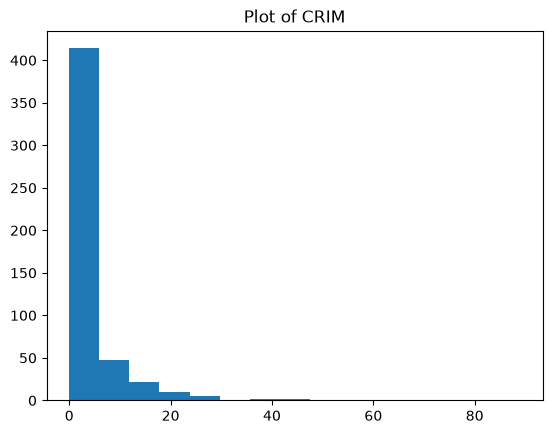

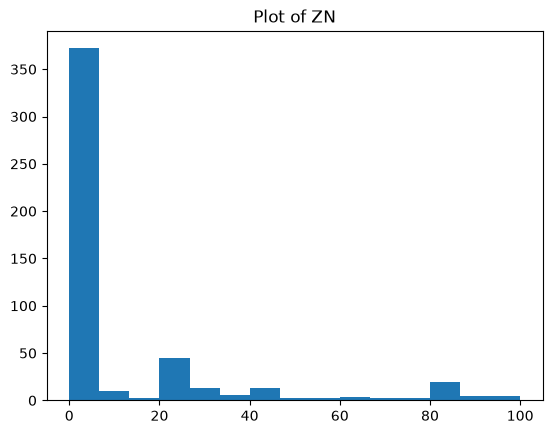

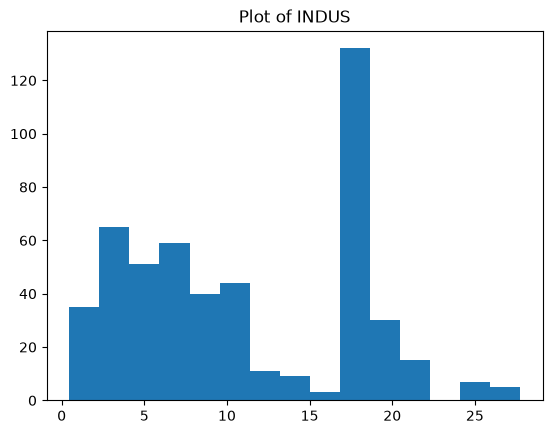

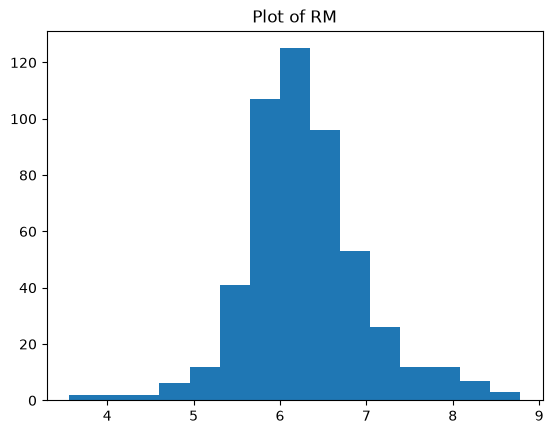

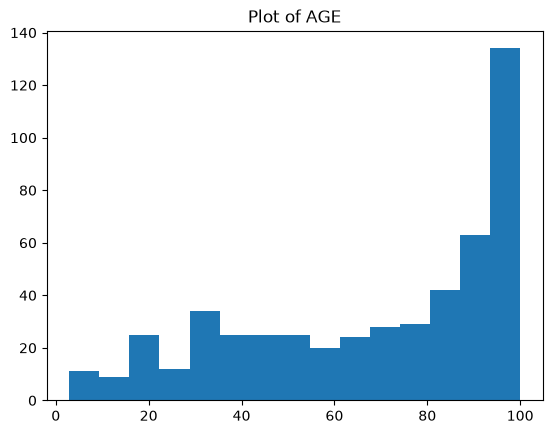

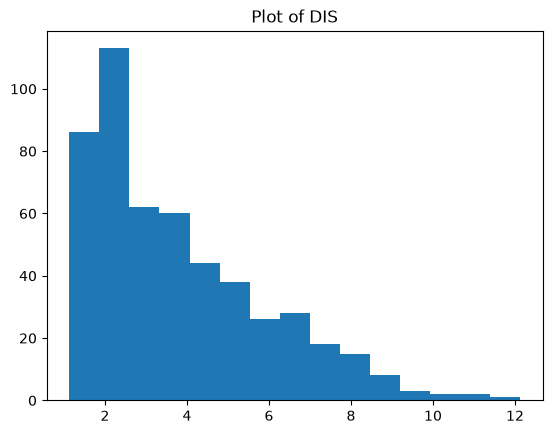

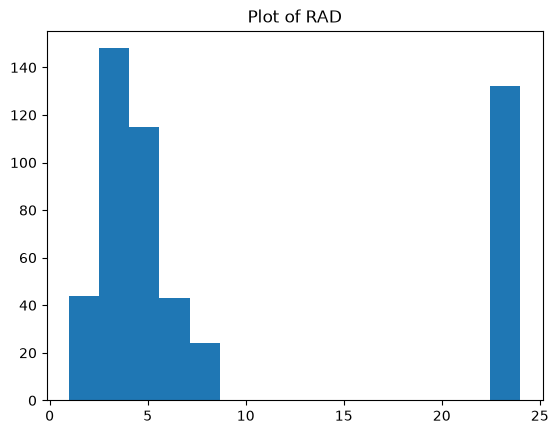

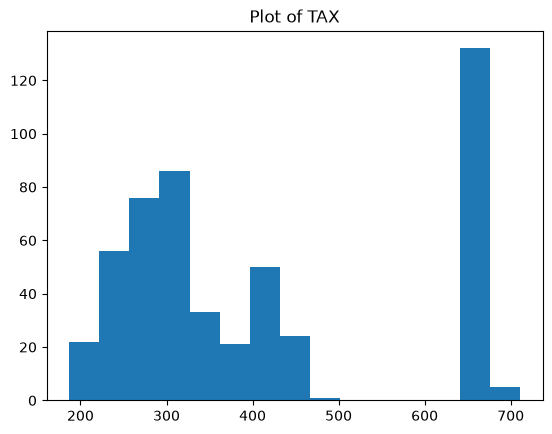

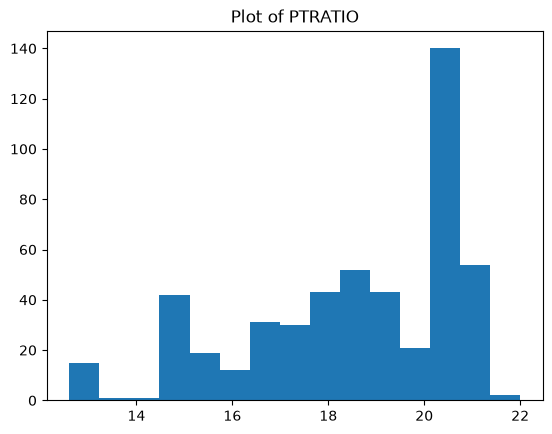

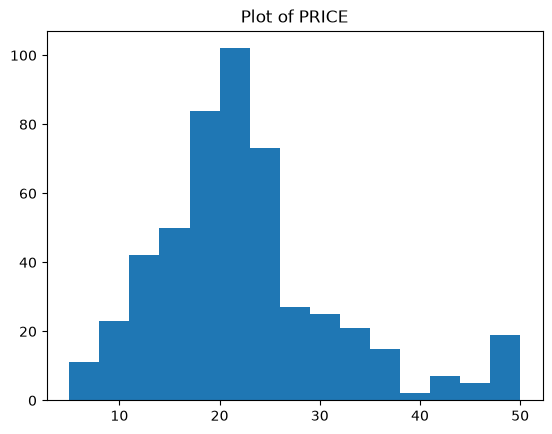

In [10]:
for c in house.columns:
    plt.title("Plot of " +c)
    plt.hist(house[c], bins=15)
    plt.show()

There is a total of 10 different histograms, each one having its own distribution. 

An additional graph will be created. A scatter plot to see the relationship between crime rate and price. 

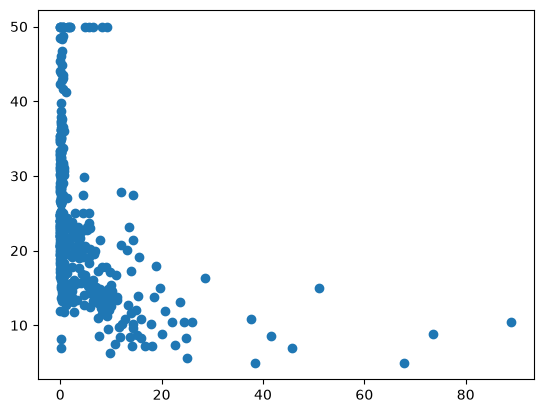

In [12]:
plt.scatter(house['CRIM'], house['PRICE'])
plt.show()

The scatter plot does not look like there is a negative or positive correlation. To make sure that there is not a correlation, the data needs to be scaled. This can be done by doing log10 on crime. 

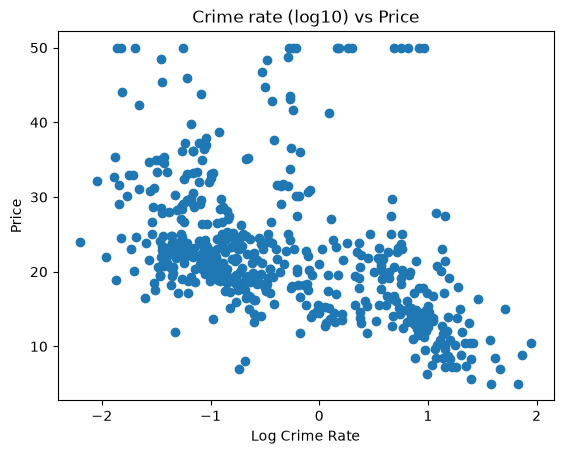

In [14]:
plt.scatter(np.log10(house['CRIM']), house['PRICE'])
plt.title("Crime rate (log10) vs Price")
plt.ylabel("Price")
plt.xlabel("Log Crime Rate")
plt.show()

Once the data has been scaled, it is easier to see the correlation between Crime rate and Price. There seems to be a moderate strong negative correlationship between the two variables. 

The next steps is to find the mean room, median age, mean distance, and the percentage of houses below $20K. 

In [15]:
house['RM'].mean()

np.float64(6.284634387351779)

In [16]:
house['AGE'].median()

np.float64(77.5)

In [17]:
house['DIS'].mean()

np.float64(3.795042687747036)

In [18]:
low = house['PRICE']<20
print(low)

0      False
1      False
2      False
3      False
4      False
       ...  
501    False
502    False
503    False
504    False
505     True
Name: PRICE, Length: 506, dtype: bool


In [19]:
low.mean()

percent = low.mean()*100
print(percent)

41.50197628458498


## Activity 2: 4.01:


In [21]:
UCI = pd.read_csv("/Users/rosienavarro/Data_Science/adult_income_data.csv")

UCI.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,Female,0,0,40,United-States,<=50K


## Activity 3: practice basic arithmetic 

In [3]:
series1 = pd.Series([7.3, -2.5, 3.4, 1.5], index = ['a', 'c', 'd', 'e'])

print(series1)

a    7.3
c   -2.5
d    3.4
e    1.5
dtype: float64


In [5]:
series2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1], index = ['a', 'c', 'e', 'f', 'g'])
print(series2)

a   -2.1
c    3.6
e   -1.5
f    4.0
g    3.1
dtype: float64


In [6]:
print(series1 + series2)

a    5.2
c    1.1
d    NaN
e    0.0
f    NaN
g    NaN
dtype: float64


In [7]:
print(series1 - series2)

a    9.4
c   -6.1
d    NaN
e    3.0
f    NaN
g    NaN
dtype: float64
